In [3]:
import ollama
from IPython.display import Image, display

In [4]:
EMBEDDING_MODEL = 'hf.co/CompendiumLabs/bge-base-en-v1.5-gguf'
LANGUAGE_MODEL = 'hf.co/bartowski/Llama-3.2-1B-Instruct-GGUF'

In [5]:
dataset = []
with open('cat-facts.txt', 'r', encoding='utf-8') as file:
  dataset = file.readlines()
  print(f'Loaded {len(dataset)} entries')

Loaded 150 entries


In [6]:
VECTOR_DB = []

In [7]:
def add_chunk_to_database(chunk):
  embedding = ollama.embed(model=EMBEDDING_MODEL, input=chunk)['embeddings'][0]
  VECTOR_DB.append((chunk, embedding))

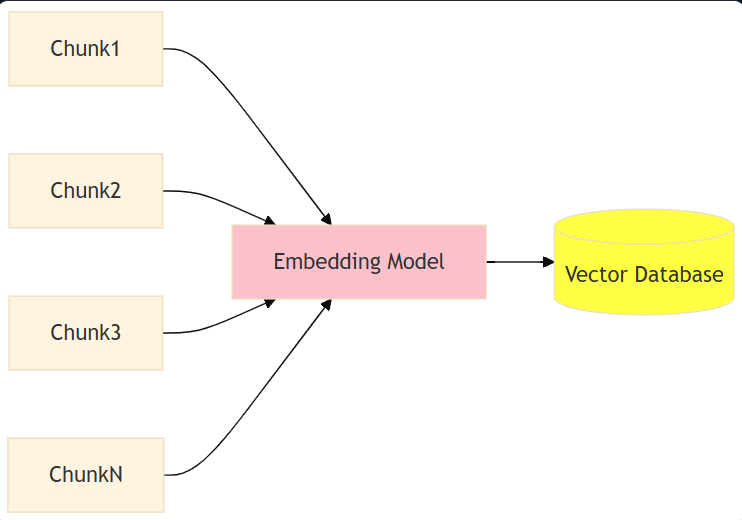

In [8]:
display(Image(filename='fig1.png', width=400))

In [9]:
for i, chunk in enumerate(dataset):
  add_chunk_to_database(chunk)
  print(f'Added chunk {i+1}/{len(dataset)} to the database')

Added chunk 1/150 to the database
Added chunk 2/150 to the database
Added chunk 3/150 to the database
Added chunk 4/150 to the database
Added chunk 5/150 to the database
Added chunk 6/150 to the database
Added chunk 7/150 to the database
Added chunk 8/150 to the database
Added chunk 9/150 to the database
Added chunk 10/150 to the database
Added chunk 11/150 to the database
Added chunk 12/150 to the database
Added chunk 13/150 to the database
Added chunk 14/150 to the database
Added chunk 15/150 to the database
Added chunk 16/150 to the database
Added chunk 17/150 to the database
Added chunk 18/150 to the database
Added chunk 19/150 to the database
Added chunk 20/150 to the database
Added chunk 21/150 to the database
Added chunk 22/150 to the database
Added chunk 23/150 to the database
Added chunk 24/150 to the database
Added chunk 25/150 to the database
Added chunk 26/150 to the database
Added chunk 27/150 to the database
Added chunk 28/150 to the database
Added chunk 29/150 to the dat

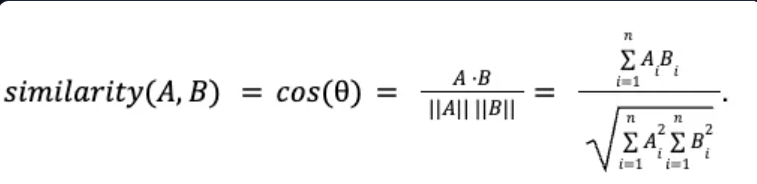

In [10]:
display(Image(filename='fig2.png', width=500))

In [11]:
def cosine_similarity(a, b):
  dot_product = sum([x * y for x, y in zip(a, b)])
  norm_a = sum([x ** 2 for x in a]) ** 0.5
  norm_b = sum([x ** 2 for x in b]) ** 0.5
  return dot_product / (norm_a * norm_b)

In [12]:
def retrieve(query, top_n=3):
  query_embedding = ollama.embed(model=EMBEDDING_MODEL, input=query)['embeddings'][0]
  # temporary list to store (chunk, similarity) pairs
  similarities = []
  for chunk, embedding in VECTOR_DB:
    similarity = cosine_similarity(query_embedding, embedding)
    similarities.append((chunk, similarity))
  # sort by similarity in descending order, because higher similarity means more relevant chunks
  similarities.sort(key=lambda x: x[1], reverse=True)
  # finally, return the top N most relevant chunks
  return similarities[:top_n]

In [13]:
input_query = input('Ask me a question: ')
retrieved_knowledge = retrieve(input_query)

print('Retrieved knowledge:')
for chunk, similarity in retrieved_knowledge:
  print(f' - (similarity: {similarity:.2f}) {chunk}')

context_chunks = '\n'.join([f' - {chunk}' for chunk, similarity in retrieved_knowledge])
instruction_prompt = f'''You are a helpful chatbot.
Use only the following pieces of context to answer the question. Don't make up any new information:
{context_chunks}'''

Retrieved knowledge:
 - (similarity: 0.76) Cats are North America’s most popular pets: there are 73 million cats compared to 63 million dogs. Over 30% of households in North America own a cat.

 - (similarity: 0.75) There are more than 500 million domestic cats in the world, with approximately 40 recognized breeds.

 - (similarity: 0.73) Most cats give birth to a litter of between one and nine kittens. The largest known litter ever produced was 19 kittens, of which 15 survived.



In [14]:
stream = ollama.chat(
  model=LANGUAGE_MODEL,
  messages=[
    {'role': 'system', 'content': instruction_prompt},
    {'role': 'user', 'content': input_query},
  ],
  stream=True,
)

# print the response from the chatbot in real-time
print('Chatbot response:')
for chunk in stream:
  print(chunk['message']['content'], end='', flush=True)

Chatbot response:
According to the context, there are:

* 73 million domestic cats in North America
* Approximately 40 recognized breeds of domestic cat worldwide

So, in total, I would say that there are around 113 million domestic cats in the world.